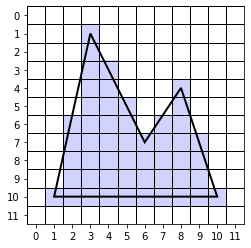

In [1]:
import numpy as np
import matplotlib.pyplot as plt     
# from myst_nb import glue
# plt.rcParams['text.usetex'] = True

  
def pixelcoordinates(X, Y, Nx, Ny):
    X = [int(x * Nx) for x in X]
    Y = [int((1 - y) * Ny) for y in Y]
    return X, Y

def drawpolygon(R, X, Y, colour):

    # Generate edge table
    n = len(X)
    ET = []
    j = n - 1
    for i in range(n):
        if Y[i] < Y[j]:
            imin, imax = i, j
        elif Y[i] > Y[j]:
            imin, imax = j, i
        else:
            j = i
            continue
            
        dx, dy = X[imin] - X[imax], Y[imin] - Y[imax]
        if dx > 0:
            xstep = -1
        elif dx < 0:
            xstep = 1
            
        ET.append([X[imin], Y[imin], Y[imax], xstep, abs(dx), abs(dy), 0])
        j = i

    # Loop through scanlines
    y = min(Y)
    AET = []
    while len(ET) > 0 or len(AET) > 0:
        
        # Move edges from ET to AET whose ymin = y
        i = 0
        while i < len(ET):
            if ET[i][1] == y:
                AET.append(ET.pop(i))
            else:
                i += 1
        
        # Sort AET by x value
        AET.sort()
        
        # Fill scanline
        i = 0
        while i < len(AET) - 1:
            R[y,AET[i][0]:AET[i+1][0] + 1,:] = colour
            i += 2
                
        # Remove edges from AET whose ymax = y
        for edge in AET.copy():
            if edge[2] == y:
                AET.remove(edge)

        # Increment y and update values in AET
        y += 1
        for edge in AET:
            edge[6] += edge[4]
            while edge[6] >= edge[5]:
                edge[6] -= edge[5]
                edge[0] += edge[3]
              
    return R 
    

blue = [210, 210, 255]
darkblue = [0, 0, 255]
grey = [128, 128, 128]

Nx, Ny = 12, 12
X = [0.1, 0.9, 0.7, 0.5, 0.3]
Y = [0.1, 0.1, 0.6, 0.4, 0.9]
X, Y = pixelcoordinates(X, Y, Nx, Ny)

img = 255 * np.ones((Nx, Ny, 3)).astype(int)
img = drawpolygon(img, X, Y, blue)

fig, ax = plt.subplots()

imgplot = plt.imshow(img)
for i in range(Nx):
    for j in range(Ny):
        ax.add_patch(plt.Rectangle((i-0.5,j-0.5), 1, 1, ec="k", fill=False))
        
plt.imshow(img)
plt.xticks(range(Nx))
plt.yticks(range(Ny))
plt.fill(X, Y, fill=False,lw=2)
# glue("scanline-example-0", fig, display=False)